## Import knižníc

Táto bunka načítava všetky potrebné knižnice pre spracovanie dát, trénovanie modelu a vizualizáciu výsledkov.

In [1]:
import os
import re
import glob
import random
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, LeakyReLU, BatchNormalization, Dropout, Input, Concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras.layers import *
from tensorflow.keras.models import load_model
import json

2026-04-17 13:42:20.047853: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Konfigurácia, načítanie datasetov a príprava dát

Táto bunka definuje základné parametre trénovania, načítava všetky dostupné datasety, vykonáva párovanie obrázkov s maskami, predspracovanie, spájanie datasetov a následné rozdelenie na trénovaciu, validačnú a testovaciu množinu. Okrem toho ukladá testovaciu množinu do samostatného adresára pre neskoršie vyhodnocovanie.

### Konfigurácia trénovania
- `IMG_SIZE` – cieľová veľkosť obrázkov pre model (384×384 px).
- `BATCH_SIZE` – počet vzoriek v jednej dávke.
- `EPOCHS` – počet trénovacích epoch.
- `datasets` – zoznam všetkých zásielok s cestami k obrázkom a ručným maskám.

### Funkcia `load_image_mask()`
Zabezpečuje načítanie a predspracovanie jedného obrázka a jeho masky:
- načítanie obrázka cez OpenCV,
- konverzia do RGB,
- zmena veľkosti na `IMG_SIZE`,
- normalizácia pixelov do rozsahu 0–1,
- načítanie masky v odtieňoch šedej,
- binarizácia masky (threshold > 128),
- rozšírenie dimenzie masky na tvar `(H, W, 1)`.

### Funkcia `load_dataset()`
Načítava celý dataset z dvoch priečinkov (obrázky + masky):
- filtruje súbory podľa prípon,
- čistí názvy súborov, aby sa dali správne spárovať,
- vytvára mapovanie `meno → cesta`,
- spáruje obrázky s maskami podľa názvu,
- načíta všetky dvojice pomocou `load_image_mask()`,
- vracia:
  - `images` – numpy pole obrázkov,
  - `masks` – numpy pole masiek,
  - `img_paths` – pôvodné cesty k obrázkom,
  - `mask_paths` – pôvodné cesty k maskám.
### Načítanie všetkých datasetov
Pre každú zásielku:
- načíta obrázky a masky,
- vypíše počet spárovaných položiek,
- pridá ich do spoločných zoznamov.

Následne sa všetky datasety spoja do jedného veľkého datasetu:
- `X_all` – všetky obrázky,
- `y_all` – všetky masky,
- `img_paths_all`, `mask_paths_all` – cesty k pôvodným súborom.

### Rozdelenie datasetu
Dataset sa rozdelí v dvoch krokoch:
1. **Train / Temp** (85 % / 15 %)
2. **Val / Test** (z Temp: 50 % / 50 %)

Výsledné množiny:
- `X_train`, `y_train`
- `X_val`, `y_val`
- `X_test`, `y_test`

Súčasne sa rozdeľujú aj cesty k obrázkom a maskám.

### Uloženie testovacej množiny
Testovacia množina sa uloží do zvoleného adresára


In [2]:
IMG_SIZE = (384, 384)
BATCH_SIZE = 8
EPOCHS = 200

datasets = [
    ("Zásielka 1", Path("../data/CropPictures/orezane_zasielka1_new"), Path("../data/RucneMasky/zasielka1")),
    ("Zásielka 2", Path("../data/CropPictures/orezane_zasielka2_new"), Path("../data/RucneMasky/zasielka2")),
    ("Zásielka 3", Path("../data/CropPictures/orezane_zasielka3_new"), Path("../data/RucneMasky/zasielka3")),
    ("Zásielka 4", Path("../data/CropPictures/orezane_zasielka4_new"), Path("../data/RucneMasky/zasielka4")),
    ("Zásielka 5", Path("../data/CropPictures/orezane_zasielka5_new"), Path("../data/RucneMasky/zasielka5")),
    ("Zásielka 6", Path("../data/CropPictures/orezane_zasielka6_new"), Path("../data/RucneMasky/zasielka6")),
    ("Zásielka 7", Path("../data/CropPictures/orezane_zasielka7_new"), Path("../data/RucneMasky/zasielka7")),
    ("Zásielka 8", Path("../data/CropPictures/orezane_zasielka8_new"), Path("../data/RucneMasky/zasielka8")),
    ("Zásielka 9", Path("../data/CropPictures/orezane_zasielka9_new"), Path("../data/RucneMasky/zasielka9")),
    ("Zásielka 10", Path("../data/CropPictures/orezane_zasielka10_new"), Path("../data/RucneMasky/zasielka10")),
    ("Zásielka 11", Path("../data/CropPictures/orezane_zasielka11_new"), Path("../data/RucneMasky/zasielka11")),
    ("Zásielka 12", Path("../data/CropPictures/orezane_zasielka12_new"), Path("../data/RucneMasky/zasielka12")),
    ("Zásielka 13", Path("../data/CropPictures/orezane_zasielka13_new"), Path("../data/RucneMasky/zasielka13")),
]

def load_image_mask(image_path, mask_path, img_size=IMG_SIZE):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, img_size, interpolation=cv2.INTER_CUBIC)
    image = image / 255.0

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, img_size, interpolation=cv2.INTER_NEAREST)
    mask = (mask > 128).astype(np.uint8)
    mask = np.expand_dims(mask, axis=-1)

    return image, mask


def load_dataset(image_folder: Path, mask_folder: Path):
    exts_img = [".jpg", ".jpeg", ".png"]
    exts_mask = [".png", ".jpg"]

    def clean_name(path: Path):
        name = path.stem.strip()
        while name.startswith(("!", "s", "S")):
            name = name[1:]
        for suffix in ["_mask", "_maska", "_seg", "-mask"]:
            name = name.replace(suffix, "")
        return name

    image_files = {clean_name(p): p for ext in exts_img for p in image_folder.glob(f"*{ext}") if p.is_file()}
    mask_files  = {clean_name(p): p for ext in exts_mask for p in mask_folder.glob(f"*{ext}") if p.is_file()}

    keys = sorted(set(image_files.keys()) & set(mask_files.keys()))
    print(f"Spárovaných: {len(keys)} obrázkov")

    images, masks, img_paths, mask_paths = [], [], [], []

    for k in keys:
        img, mask = load_image_mask(image_files[k], mask_files[k])
        images.append(img)
        masks.append(mask)
        img_paths.append(image_files[k])
        mask_paths.append(mask_files[k])

    return (
        np.array(images, np.float32),
        np.array(masks, np.uint8),
        np.array(img_paths),
        np.array(mask_paths),
    )

# NAČÍTANIE DÁT 
all_images = []
all_masks = []
all_img_paths = []
all_mask_paths = []

print("\n=== Načítavanie datasetov ===")
for name, img_path, mask_path in datasets:
    print(f"\n{name}:")
    Xtmp, ytmp, iptmp, mptmp = load_dataset(img_path, mask_path)
    print(f"Načítaných dokopy: {Xtmp.shape[0]}")

    all_images.append(Xtmp)
    all_masks.append(ytmp)
    all_img_paths.append(iptmp)
    all_mask_paths.append(mptmp)

X_all = np.concatenate(all_images, axis=0)
y_all = np.concatenate(all_masks, axis=0)
img_paths_all = np.concatenate(all_img_paths, axis=0)
mask_paths_all = np.concatenate(all_mask_paths, axis=0)

print(f"\nSpolu všetkých obrázkov: {X_all.shape[0]}")

# SPLIT 
X_train, X_temp, y_train, y_temp, ip_train, ip_temp, mp_train, mp_temp = train_test_split(
    X_all, y_all, img_paths_all, mask_paths_all,
    test_size=0.15,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test, ip_val, ip_test, mp_val, mp_test = train_test_split(
    X_temp, y_temp, ip_temp, mp_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("\n=== Výsledné rozdelenie ===")
print(f"Train: {X_train.shape[0]}")
print(f"Val:   {X_val.shape[0]}")
print(f"Test:  {X_test.shape[0]}")

# ULOŽENIE TEST SETU
test_root = Path("test_pix2pix_all_data")
test_img_dir = test_root / "images"
test_mask_dir = test_root / "masks"

test_img_dir.mkdir(parents=True, exist_ok=True)
test_mask_dir.mkdir(parents=True, exist_ok=True)

for img_path, mask_path in zip(ip_test, mp_test):
    img = cv2.imread(str(img_path))
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    cv2.imwrite(str(test_img_dir / img_path.name), img)
    cv2.imwrite(str(test_mask_dir / mask_path.name), mask)

print(f"\nTestovacia množina uložená do: {test_root}")



=== Načítavanie datasetov ===

Zásielka 1:
Spárovaných: 16 obrázkov
Načítaných dokopy: 16

Zásielka 2:
Spárovaných: 36 obrázkov
Načítaných dokopy: 36

Zásielka 3:
Spárovaných: 301 obrázkov
Načítaných dokopy: 301

Zásielka 4:
Spárovaných: 72 obrázkov
Načítaných dokopy: 72

Zásielka 5:
Spárovaných: 21 obrázkov
Načítaných dokopy: 21

Zásielka 6:
Spárovaných: 121 obrázkov
Načítaných dokopy: 121

Zásielka 7:
Spárovaných: 72 obrázkov
Načítaných dokopy: 72

Zásielka 8:
Spárovaných: 48 obrázkov
Načítaných dokopy: 48

Zásielka 9:
Spárovaných: 41 obrázkov
Načítaných dokopy: 41

Zásielka 10:
Spárovaných: 54 obrázkov
Načítaných dokopy: 54

Zásielka 11:
Spárovaných: 45 obrázkov
Načítaných dokopy: 45

Zásielka 12:
Spárovaných: 118 obrázkov
Načítaných dokopy: 118

Zásielka 13:
Spárovaných: 39 obrázkov
Načítaných dokopy: 39

Spolu všetkých obrázkov: 984

=== Výsledné rozdelenie ===
Train: 836
Val:   74
Test:  74

Testovacia množina uložená do: test_pix2pix_all_data


## Augmentácia

Táto bunka definuje funkciu **augmentáciu dát**, ktorá generuje viacero variácií jedného obrázka a jeho masky. Cieľom je zvýšiť robustnosť modelu a zlepšiť generalizáciu pri trénovaní.

Funkcia `augment_combined()` vykonáva viacero typov transformácií, pričom zabezpečuje, aby boli **obrázok aj maska transformované konzistentne**.

### Funkcia `augment_combined(image, mask, num_aug=2)`

Funkcia vytvorí `num_aug` augmentovaných verzií vstupného obrázka a masky. Výstupom sú dva zoznamy:
- `aug_images` – pôvodný + augmentované obrázky,
- `aug_masks` – pôvodná + augmentované masky.

### Aplikované augmentácie

#### **Rotácia a posun**  
S pravdepodobnosťou 0.9 sa vykoná:
- rotácia v rozsahu ±5°,
- horizontálny a vertikálny posun (±10 px),

#### **Zmena jasu / gamma korekcia**  
S pravdepodobnosťou 0.9:
- aplikácia gamma transformácie v rozsahu 0.7–1.6,

#### **Gaussov šum**  
S pravdepodobnosťou 0.7:
- pridanie mierneho šumu (σ = 0.03),

#### **Vertikálne dropout pásy**  
S pravdepodobnosťou 0.7:
- náhodné zatemnenie úzkych vertikálnych pásov,

#### **Rozmazanie (Gaussian blur)**  
S pravdepodobnosťou 0.5:
- aplikácia blur filtra s kernelom 3×3 alebo 5×5,

#### **Binarizácia masky**  
Po všetkých transformáciách sa maska opäť binarizuje:
- hodnoty > 0.5 → 1  
- inak → 0  

In [3]:
def augment_combined(image, mask, num_aug=2):
    # zaruč masku ako (H,W,1)
    if mask.ndim == 2:
        mask = np.expand_dims(mask, axis=-1)

    image = image.astype(np.float32)
    if image.max() > 1.5:
        image = image / 255.0

    h, w = IMG_SIZE

    aug_images = [image]
    aug_masks = [mask]

    for _ in range(num_aug):
        img_aug = image.copy()
        mask_aug = mask.copy()

        # Rotácia + posun
        if random.random() < 0.9:
            angle = random.uniform(-5, 5)
            tx = random.uniform(-10, 10)
            ty = random.uniform(-10, 10)

            M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1)
            M[0, 2] += tx
            M[1, 2] += ty

            img_aug = cv2.warpAffine(
                img_aug,
                M,
                (w, h),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_REFLECT,
            )

            mask_aug = cv2.warpAffine(
                mask_aug[..., 0],
                M,
                (w, h),
                flags=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_REFLECT,
            )

            mask_aug = np.expand_dims(mask_aug, axis=-1)

        # Jas / gamma 
        if random.random() < 0.9:
            gamma = random.uniform(0.7, 1.6)
            img_aug = np.power(np.clip(img_aug, 0, 1), gamma)

        # Gaussov šum 
        if random.random() < 0.7:
            noise = np.random.normal(0, 0.03, img_aug.shape).astype(np.float32)
            img_aug = np.clip(img_aug + noise, 0, 1)

        # Dropout vertikálne pásy 
        if random.random() < 0.7:
            num_stripes = random.randint(1, 5)
            for _ in range(num_stripes):
                x0 = random.randint(0, w - 10)
                stripe_w = random.randint(3, 12)
                img_aug[:, x0:x0 + stripe_w, :] = 0.0

        # Blur 
        if random.random() < 0.5:
            k = random.choice([3, 5])
            img_aug = cv2.GaussianBlur(img_aug, (k, k), 0)

        # binarizácia masky
        mask_aug = (mask_aug > 0.5).astype(np.uint8)

        aug_images.append(img_aug)
        aug_masks.append(mask_aug)

    return aug_images, aug_masks


## Spustenie kombinovanej augmentácie nad trénovacou množinou

V tejto bunke sa vykonáva hromadná augmentácia všetkých obrázkov v trénovacej množine. Pre každý obrázok a jeho dilatovanú masku sa vygenerujú viaceré nové varianty pomocou funkcie `augment_combined()`.

### Priebeh augmentácie
- Pre každý obrázok v `X_train` a jeho masku v `y_train_dilated` sa zavolá:

Funkcia `augment_combined` vráti:
- pôvodný obrázok + 3 augmentované verzie,
- pôvodnú masku + 3 augmentované verzie.
- Všetky výsledky sa postupne ukladajú do zoznamov `augmented_images` a `augmented_masks`.

### Výsledná trénovacia množina
Po ukončení augmentácie sa zoznamy skonvertujú na numpy polia:
- `X_train_final` – finálna množina obrázkov pre tréning,
- `y_train_final` – finálna množina masiek.



In [4]:
print("Prebieha augmentácia")

augmented_images = []
augmented_masks = []

for img, mask in zip(X_train, y_train):
    ai, am = augment_combined(img, mask, num_aug=3) 
    augmented_images.extend(ai)
    augmented_masks.extend(am)

X_train_final = np.array(augmented_images, dtype=np.float32)
y_train_final = np.array(augmented_masks, dtype=np.uint8)

print(f"Tréningová sada po augmentácii: {len(X_train_final)} (pôvodne {len(X_train)})")


Prebieha augmentácia
Tréningová sada po augmentácii: 3344 (pôvodne 836)


## Metriky a stratové funkcie

Táto bunka definuje metriky a stratové funkcie používané pri trénovaní segmentačného modelu:

- **Discriminator loss**
- **Dice loss**
- **Combined loss**
- **Generator loss** 
- **Dice score** 
- **IoU score** 


In [5]:
LAMBDA = 100
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output)*0.9, disc_real_output)
    fake_loss = loss_object(tf.zeros_like(disc_generated_output)+0.1, disc_generated_output)
    return real_loss + fake_loss

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.sigmoid(y_pred)
    inter = tf.reduce_sum(y_true * y_pred)
    denom = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return 1 - (2.*inter + smooth)/(denom + smooth)

def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + tf.keras.losses.BinaryCrossentropy(from_logits=False)(y_true, y_pred)

def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    dice_bce = combined_loss(target, gen_output)
    return gan_loss + (LAMBDA * dice_bce)

def dice_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    denom = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return (2.*inter + smooth)/(denom + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - inter
    return (inter + smooth)/(union + smooth)


## Architektúra Pix2Pix  
### Definícia generátora a diskriminátora

Táto časť opisuje implementáciu modelu **Pix2Pix**, ktorý pozostáva z dvoch hlavných komponentov:

- **Generator (U‑Net architektúra)** – prevádza vstupný obrázok na výstupnú masku.
- **Discriminator (PatchGAN)** – hodnotí, či je dvojica *(vstup, výstup)* reálna alebo generovaná.

## Generator – U‑Net architektúra

Funkcia `build_generator()` vytvára encoder‑decoder sieť s preskakovacími prepojeniami (skip connections).  
Vstupom je obrázok **384×384×3**, výstupom je binárna maska **384×384×1** so sigmoid aktiváciou.

### **Downsampling bloky**
Implementované funkciou `downsample(filters, size)`:

- 2D konvolúcia so stride 2 (zmenšenie rozlíšenia),
- voliteľná `BatchNormalization`,
- `LeakyReLU` aktivácia,
- postupné zvyšovanie počtu filtrov: **64 → 128 → 256 → 512 × 4**.

Downsampling extrahuje čoraz abstraktnejšie príznaky a tvorí encoder časť U‑Netu.

### **Upsampling bloky**
Implementované funkciou `upsample(filters, size)`:

- transponovaná konvolúcia (zväčšenie rozlíšenia),
- `BatchNormalization`,
- voliteľný `Dropout(0.5)` v prvých troch vrstvách,
- `ReLU` aktivácia.

Upsampling obnovuje priestorové rozlíšenie a postupne rekonštruuje výstupnú masku.

### **Skip connections**
- Každý upsampling blok je spojený s príslušným downsampling výstupom.
- Umožňuje preniesť nízkoúrovňové detaily, ktoré by sa inak stratili.
- Zlepšuje ostrosť a presnosť segmentácie.

### **Finálna vrstva**
- `Conv2DTranspose(1, 4, strides=2, activation='sigmoid')`
- Výstup: **binárna maska** v rozsahu ⟨0, 1⟩.

### **Výstup funkcie**
`build_generator()` vracia plne zostavený U‑Net generátor pripravený na trénovanie v Pix2Pix frameworku.

## Discriminator – PatchGAN

Funkcia `build_discriminator()` implementuje **PatchGAN** diskriminátor, ktorý klasifikuje malé lokálne oblasti (patches) ako reálne alebo generované.

### Vstupy
- **inp** – pôvodný obrázok (384×384×3),
- **tar** – cieľová alebo generovaná maska (384×384×1),
- oba vstupy sa spoja pomocou `Concatenate`.

### Architektúra
Skladá sa zo série konvolučných blokov:

- Konvolúcie s filtrami **64 → 128 → 256 → 512**,
- stride = 2 pre postupné zmenšovanie rozlíšenia,
- `BatchNormalization` (okrem prvej vrstvy),
- `LeakyReLU` aktivácia.

### Výstupná vrstva
- `Conv2D(1, 4, strides=1, activation='sigmoid')`
- Výstupom je mapa pravdepodobností, kde každý pixel reprezentuje hodnotenie jedného patchu.

### **Výstup funkcie**
`build_discriminator()` vracia PatchGAN diskriminátor, ktorý sa trénuje súčasne s generátorom v rámci adversariálneho učenia.


In [6]:
def build_generator():
    inputs = Input(shape=(384, 384, 3))

    def downsample(filters, size, apply_batchnorm=True):
        seq = tf.keras.Sequential()
        seq.add(Conv2D(filters, size, strides=2, padding='same', use_bias=False))
        if apply_batchnorm:
            seq.add(BatchNormalization())
        seq.add(LeakyReLU())
        return seq

    def upsample(filters, size, apply_dropout=False):
        seq = tf.keras.Sequential()
        seq.add(Conv2DTranspose(filters, size, strides=2, padding='same', use_bias=False))
        seq.add(BatchNormalization())
        if apply_dropout:
            seq.add(Dropout(0.5))
        seq.add(ReLU())
        return seq

    
    down_stack = [
        downsample(64, 4, apply_batchnorm=False),  
        downsample(128, 4),                       
        downsample(256, 4),                       
        downsample(512, 4),                       
        downsample(512, 4),                       
        downsample(512, 4),                       
        downsample(512, 4),                       
    ]

    
    up_stack = [
        upsample(512, 4, apply_dropout=True),     
        upsample(512, 4, apply_dropout=True),     
        upsample(512, 4, apply_dropout=True),     
        upsample(512, 4),                         
        upsample(256, 4),                         
        upsample(128, 4),                         
        upsample(64, 4),                          
    ]

    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)
    skips = reversed(skips[:-1])

    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = Concatenate()([x, skip])

    last = Conv2DTranspose(1, 4, strides=2, padding='same', activation='sigmoid')
    x = last(x)
    return Model(inputs, x)

def build_discriminator():
    inp = Input(shape=(384,384,3))
    tar = Input(shape=(384,384,1))
    x = Concatenate()([inp, tar])
    for f in [64,128,256,512]:
        x = Conv2D(f,4,strides=2,padding='same')(x)
        x = BatchNormalization()(x)
        x = LeakyReLU()(x)
    out = Conv2D(1,4,strides=1,padding='same',activation='sigmoid')(x)
    return Model([inp,tar], out)

## Tréningový model Pix2Pix – Custom Keras Model

Trieda `Pix2PixModel` rozširuje `tf.keras.Model` a implementuje kompletnú tréningovú logiku pre architektúru Pix2Pix. Obsahuje prepojenie generátora, diskriminátora a ich optimalizátorov, ako aj definíciu metrik pre tréning a validáciu.

### Hlavné komponenty

### **Inicializácia**
Model prijíma:
- **generator** – U‑Net generátor,
- **discriminator** – PatchGAN diskriminátor,
- **g_opt**, **d_opt** – optimalizátory pre obe siete.

Súčasťou sú aj trackery:
- `gen_loss_tracker` – strata generátora,
- `disc_loss_tracker` – strata diskriminátora,
- `val_loss_tracker` – validačná strata,
- `val_dice_metric` – validačný Dice score.

### **Tréningový krok (`train_step`)**
- Generátor vytvorí predikciu `gen_out`.
- Diskriminátor vyhodnotí reálne aj generované dvojice.
- Počítajú sa straty:
  - `g_loss` – kombinácia adversariálnej a L1/rekonštrukčnej straty,
  - `d_loss` – diskriminačná strata pre reálne a falošné vzorky.
- Gradienty sa aplikujú na obe siete.
- Trackery sa aktualizujú.

### **Validačný krok (`test_step`)**
- Generátor vytvorí predikciu bez trénovania.
- Diskriminátor hodnotí len generované vzorky.
- Počíta sa validačná strata a Dice score.
- Trackery sa aktualizujú.

### **Výstup**
Trieda vracia slovník s metrikami pre TensorBoard alebo Jupyter výpis:
- `gen_loss`, `disc_loss` počas tréningu,
- `loss`, `dice_score` počas validácie.


In [7]:
class Pix2PixModel(tf.keras.Model):
    def __init__(self, generator, discriminator, g_opt, d_opt, **kwargs):
        super().__init__(**kwargs)
        self.generator = generator
        self.discriminator = discriminator
        self.g_opt = g_opt
        self.d_opt = d_opt
        self.gen_loss_tracker = tf.keras.metrics.Mean(name="gen_loss")
        self.disc_loss_tracker = tf.keras.metrics.Mean(name="disc_loss")
        self.val_loss_tracker = tf.keras.metrics.Mean(name="val_loss")
        self.val_dice_metric = tf.keras.metrics.Mean(name="val_dice_score")

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker, self.val_loss_tracker, self.val_dice_metric]

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as gt, tf.GradientTape() as dt:
            gen_out = self.generator(x, training=True)
            d_real = self.discriminator([x,y], training=True)
            d_fake = self.discriminator([x,gen_out], training=True)
            g_loss = generator_loss(d_fake, gen_out, y)
            d_loss = discriminator_loss(d_real, d_fake)
        g_grads = gt.gradient(g_loss, self.generator.trainable_variables)
        d_grads = dt.gradient(d_loss, self.discriminator.trainable_variables)
        self.g_opt.apply_gradients(zip(g_grads, self.generator.trainable_variables))
        self.d_opt.apply_gradients(zip(d_grads, self.discriminator.trainable_variables))
        self.gen_loss_tracker.update_state(g_loss)
        self.disc_loss_tracker.update_state(d_loss)
        return {"gen_loss": self.gen_loss_tracker.result(), "disc_loss": self.disc_loss_tracker.result()}

    def test_step(self, data):
        x, y = data
        gen_out = self.generator(x, training=False)
        d_fake = self.discriminator([x, gen_out], training=False)
        val_loss = generator_loss(d_fake, gen_out, y)
        val_dice = dice_score(y, gen_out)
        self.val_loss_tracker.update_state(val_loss)
        self.val_dice_metric.update_state(val_dice)
        return {"loss": self.val_loss_tracker.result(), "dice_score": self.val_dice_metric.result()}



## Callbacky pre trénovanie Pix2Pix

Táto časť obsahuje vlastné callbacky použité počas trénovania modelu Pix2Pix.  
Callbacky rozširujú funkcionalitu Keras tréningovej slučky o ukladanie najlepšieho modelu, vizualizáciu predikcií a správu checkpointov.

## SaveBestFullGenerator

Callback `SaveBestFullGenerator` sleduje vybranú validačnú metriku (predvolene `val_dice_score`) a pri jej zlepšení uloží celý generátor na disk.

## ShowPredictionCallback

Callback `ShowPredictionCallback` vizualizuje priebeh učenia generátora tým, že po každej epoche zobrazí:

- vstupný obrázok,
- ground‑truth masku,
- binárnu predikciu generátora.

## EpochCheckpoint

Callback `EpochCheckpoint` ukladá TensorFlow checkpointy po každej epoche.


In [8]:

class SaveBestFullGenerator(tf.keras.callbacks.Callback):
    def __init__(self, generator, filepath, monitor="val_dice_score", mode="max"):
        super().__init__()
        self.generator = generator
        self.filepath = filepath
        self.monitor = monitor
        self.mode = mode
        self.best = -np.inf if mode=="max" else np.inf
    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is not None:
            if (self.mode=="max" and current>self.best) or (self.mode=="min" and current<self.best):
                self.best = current
                self.generator.save(self.filepath)
                print(f"\n[Best model saved] Epoch {epoch+1} – {self.monitor}: {current:.4f}")

class ShowPredictionCallback(tf.keras.callbacks.Callback):
    def __init__(self, generator, test_image, test_mask, epoch_interval=1):
        super().__init__()
        self.generator = generator
        self.test_image = np.expand_dims(test_image,0)
        self.test_mask = test_mask
        self.epoch_interval = epoch_interval
    def on_epoch_end(self, epoch, logs=None):
        if (epoch+1)%self.epoch_interval==0:
            pred = self.generator.predict(self.test_image)[0,...,0]
            plt.figure(figsize=(12,4))
            plt.subplot(1,3,1); plt.imshow(self.test_image[0]); plt.axis('off'); plt.title("Input")
            plt.subplot(1,3,2); plt.imshow(self.test_mask[...,0],cmap='gray'); plt.axis('off'); plt.title("Mask")
            plt.subplot(1,3,3); plt.imshow(pred>0.5,cmap='gray'); plt.axis('off'); plt.title(f"Pred (epoch {epoch+1})")
            plt.tight_layout(); plt.show()


class EpochCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, ckpt, manager):
        super().__init__()
        self.ckpt = ckpt; self.manager = manager
    def on_epoch_end(self, epoch, logs=None):
        self.ckpt.epoch.assign(epoch+1)
        self.manager.save()
        print(f"[Checkpoint saved] Epoch {epoch+1}")

## Tréning Pix2Pix – Inicializácia modelu, dát a callbackov

Táto časť obsahuje kompletné nastavenie tréningového procesu pre model Pix2Pix:  
vytvorenie generátora a diskriminátora, prípravu datasetov, konfiguráciu checkpointov a spustenie tréningu.

## Inicializácia modelov a optimalizátorov

- Generátor a diskriminátor sa vytvoria pomocou funkcií `build_generator()` a `build_discriminator()`.
- Oba modely používajú optimalizátor **Adam** s parametrami odporúčanými v pôvodnej Pix2Pix práci:
  - learning rate: `2e-4`
  - `beta_1 = 0.5`

Model Pix2Pix je zabalený do triedy `Pix2PixModel`, ktorá definuje vlastnú tréningovú slučku.


## Príprava datasetov

Tréningové a validačné dáta sa konvertujú na `tf.data.Dataset`:

- tréningový dataset: miešanie, batching, prefetching,
- validačný dataset: batching + prefetching.

Použité sú finálne predspracované dáta:
- `X_train_final`, `y_train_final`
- `X_val`, `y_val`


## Checkpointing

Checkpointy sa ukladajú do adresára `./ckpts_pix2pix_all_data`.

Ukladá sa:
- generátor,
- diskriminátor,
- oba optimalizátory,
- index epochy.

Ak existuje posledný checkpoint, tréning pokračuje od uloženého stavu.


## Callbacky

Použité callbacky:

- **ShowPredictionCallback**  
  Vizualizuje predikciu generátora po každej epoche.

- **SaveBestFullGenerator**  
  Ukladá najlepší generátor podľa `val_dice_score`.

- **EpochCheckpoint**  
  Ukladá checkpoint po každej epoche.

- **EarlyStopping**  
  Zastaví tréning pri nezlepšovaní `val_dice_score`.

## Spustenie tréningu

Model sa kompiluje (bez explicitného zadania loss funkcie, keďže je definovaná v `train_step`)  
a následne sa spustí tréning pomocou `fit()`:

- tréningový dataset,
- validačný dataset,
- callbacky,
- pokračovanie od poslednej epochy (ak existuje checkpoint).

Výstupom sú priebežné straty generátora, diskriminátora a validačné metriky.



Začínam tréning od začiatku
Epoch 1/200
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - disc_loss: 0.9798 - gen_loss: 114.3299
[Best model saved] Epoch 1 – val_dice_score: 0.5264
[Checkpoint saved] Epoch 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


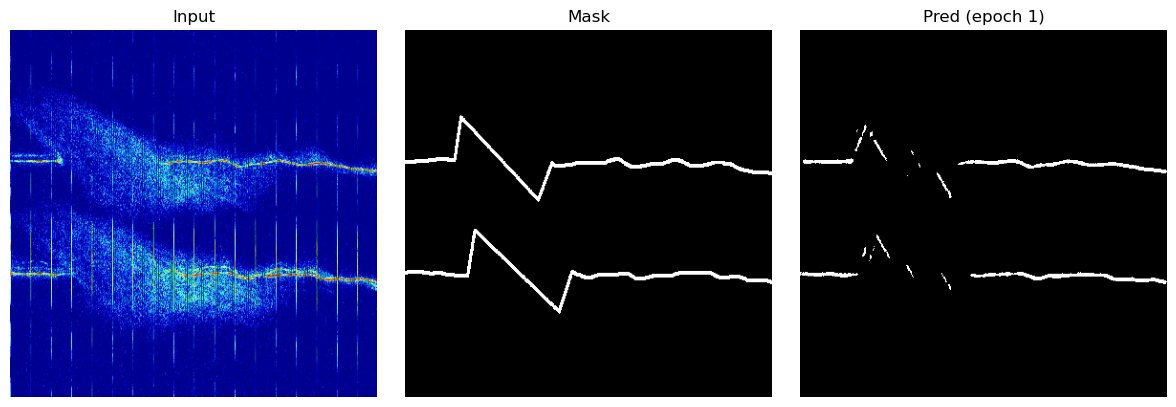

418/418 ━━━━━━━━━━━━━━━━━━━━ 1502s 4s/step - disc_loss: 0.9794 - gen_loss: 114.3116 - val_dice_score: 0.5264 - val_loss: 100.8653
Epoch 2/200
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - disc_loss: 0.7318 - gen_loss: 102.5695
[Best model saved] Epoch 2 – val_dice_score: 0.6024
[Checkpoint saved] Epoch 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


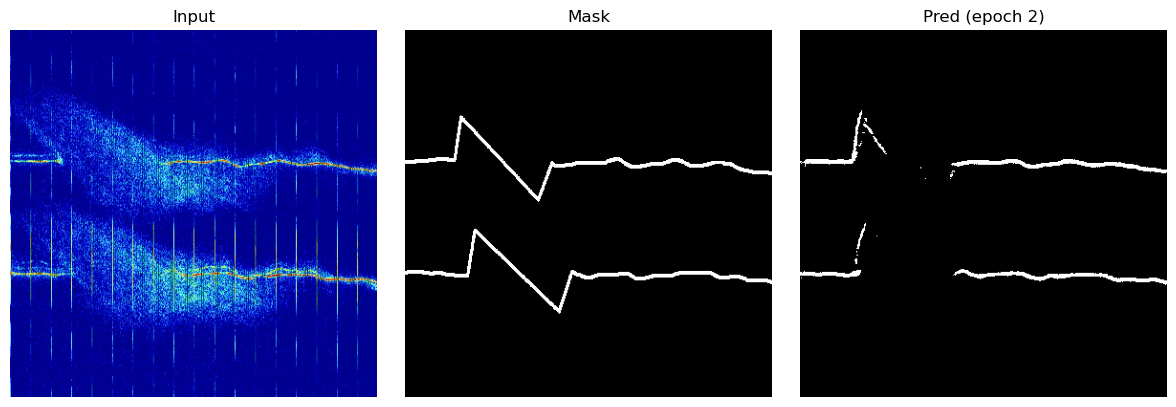

418/418 ━━━━━━━━━━━━━━━━━━━━ 1460s 3s/step - disc_loss: 0.7318 - gen_loss: 102.5689 - val_dice_score: 0.6024 - val_loss: 99.6654
Epoch 3/200
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - disc_loss: 0.6586 - gen_loss: 101.3298
[Best model saved] Epoch 3 – val_dice_score: 0.6266
[Checkpoint saved] Epoch 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


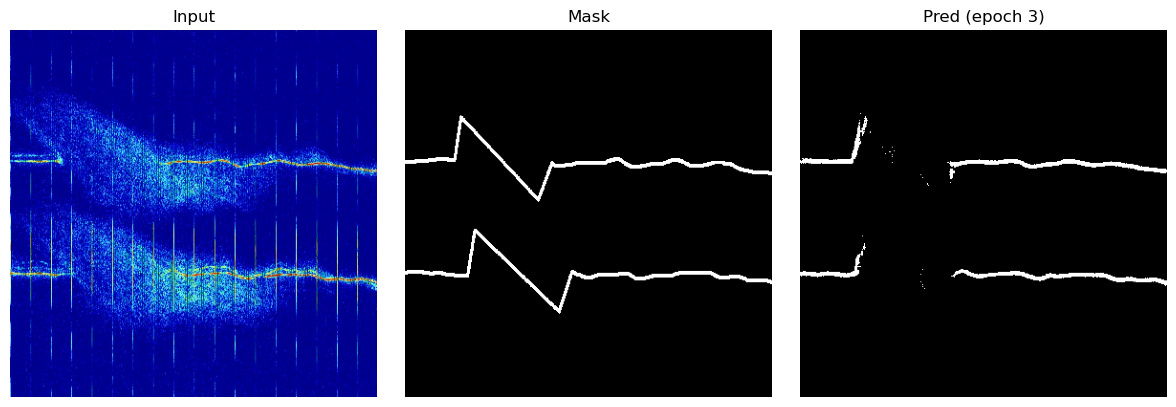

418/418 ━━━━━━━━━━━━━━━━━━━━ 1470s 4s/step - disc_loss: 0.6586 - gen_loss: 101.3296 - val_dice_score: 0.6266 - val_loss: 99.3500
Epoch 4/200
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - disc_loss: 0.6637 - gen_loss: 100.8179[Checkpoint saved] Epoch 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


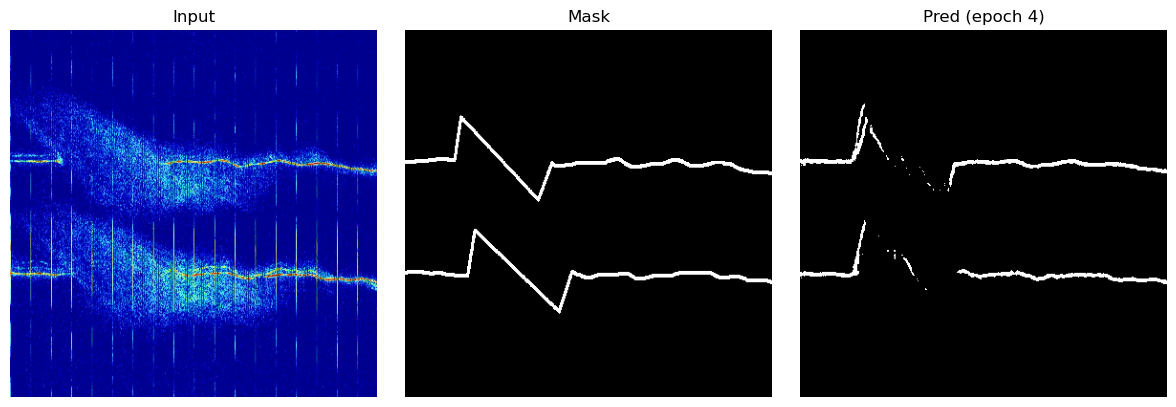

418/418 ━━━━━━━━━━━━━━━━━━━━ 1457s 3s/step - disc_loss: 0.6638 - gen_loss: 100.8176 - val_dice_score: 0.6139 - val_loss: 99.6037
Epoch 5/200
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - disc_loss: 0.7495 - gen_loss: 101.1704[Checkpoint saved] Epoch 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


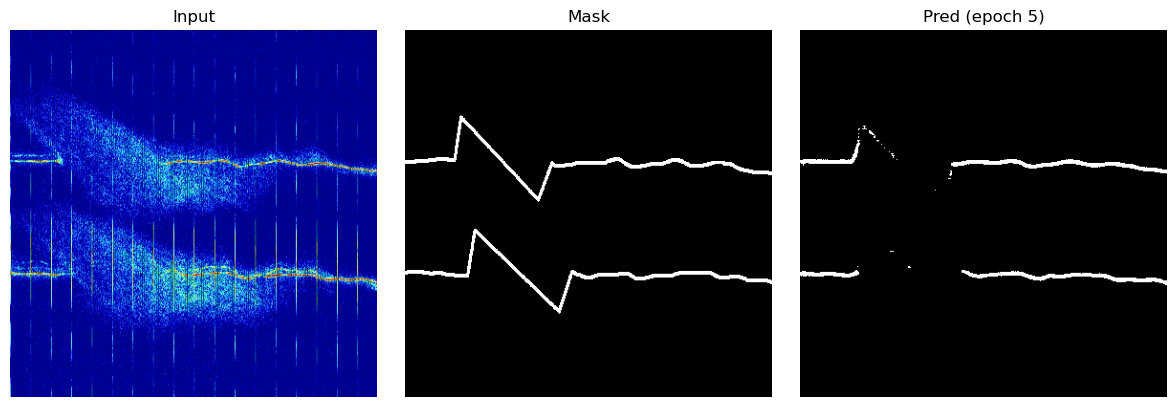

418/418 ━━━━━━━━━━━━━━━━━━━━ 1454s 3s/step - disc_loss: 0.7494 - gen_loss: 101.1698 - val_dice_score: 0.6261 - val_loss: 99.4400
Epoch 6/200
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - disc_loss: 0.6529 - gen_loss: 100.1077
[Best model saved] Epoch 6 – val_dice_score: 0.6380
[Checkpoint saved] Epoch 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


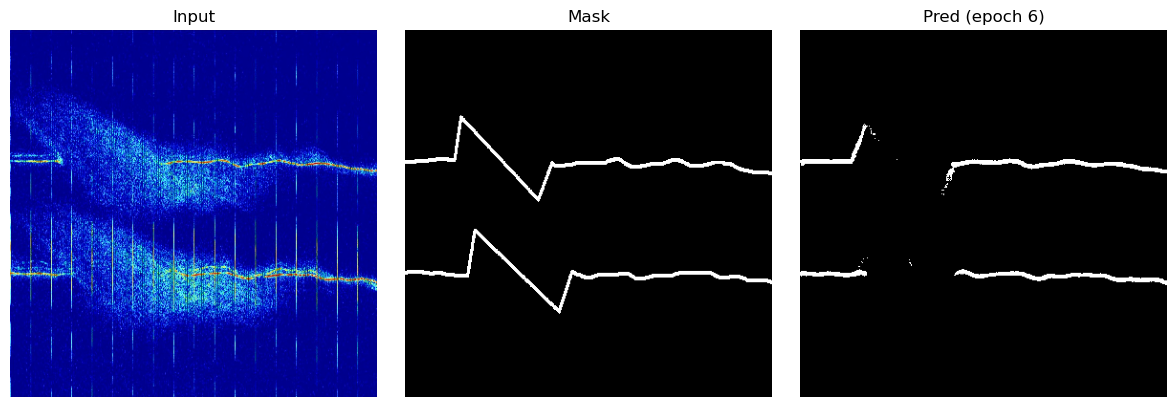

418/418 ━━━━━━━━━━━━━━━━━━━━ 1448s 3s/step - disc_loss: 0.6529 - gen_loss: 100.1075 - val_dice_score: 0.6380 - val_loss: 99.2187
Epoch 7/200
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - disc_loss: 0.6518 - gen_loss: 99.7824[Checkpoint saved] Epoch 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


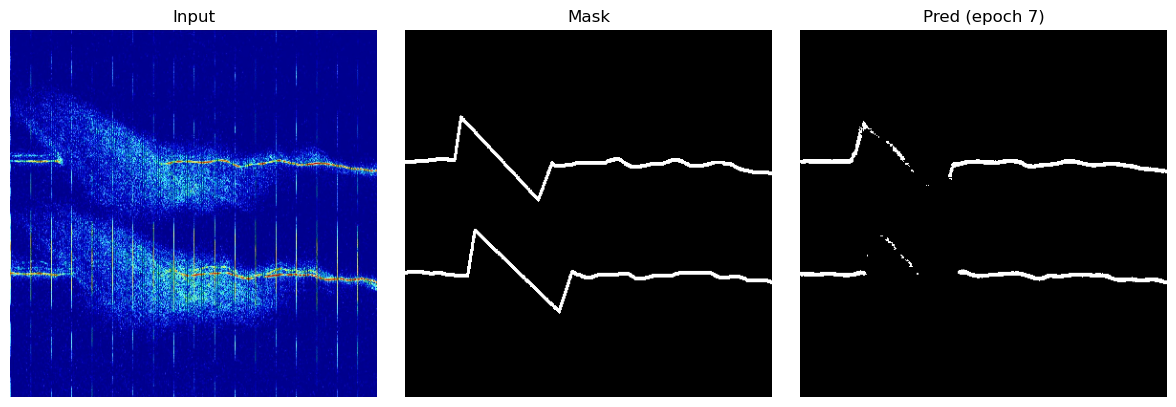

418/418 ━━━━━━━━━━━━━━━━━━━━ 1456s 3s/step - disc_loss: 0.6518 - gen_loss: 99.7823 - val_dice_score: 0.6349 - val_loss: 99.4591
Epoch 8/200
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - disc_loss: 0.6529 - gen_loss: 99.5440[Checkpoint saved] Epoch 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


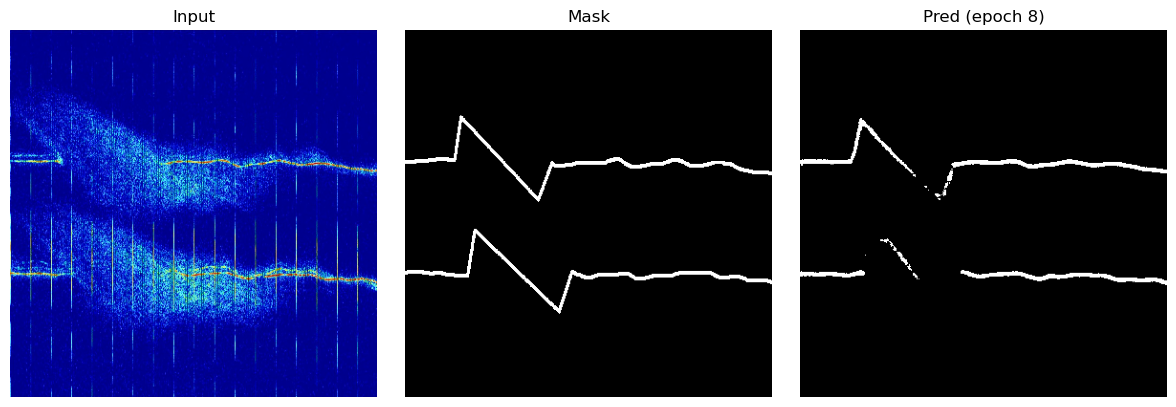

418/418 ━━━━━━━━━━━━━━━━━━━━ 1453s 3s/step - disc_loss: 0.6529 - gen_loss: 99.5438 - val_dice_score: 0.6321 - val_loss: 99.6537
Epoch 9/200
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - disc_loss: 0.7178 - gen_loss: 99.2558[Checkpoint saved] Epoch 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


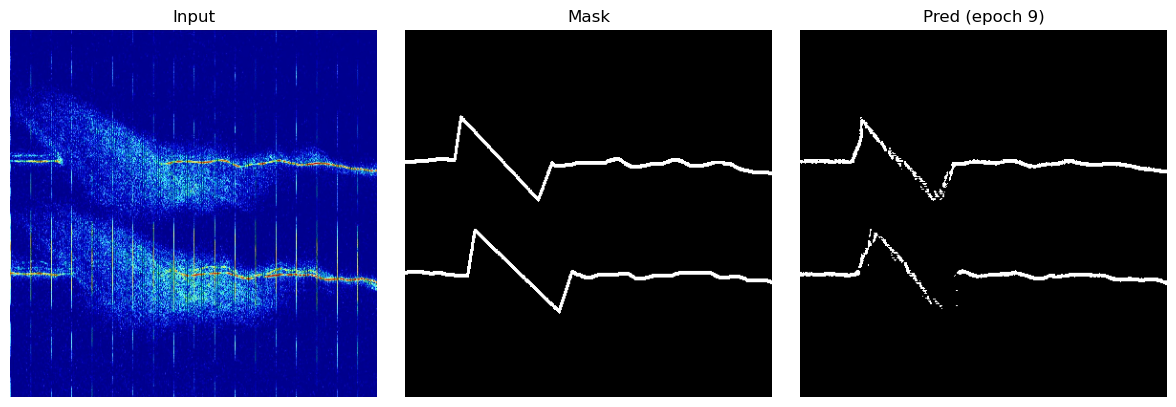

418/418 ━━━━━━━━━━━━━━━━━━━━ 1447s 3s/step - disc_loss: 0.7180 - gen_loss: 99.2561 - val_dice_score: 0.6212 - val_loss: 100.7138
Epoch 10/200
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - disc_loss: 0.7369 - gen_loss: 99.9679[Checkpoint saved] Epoch 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


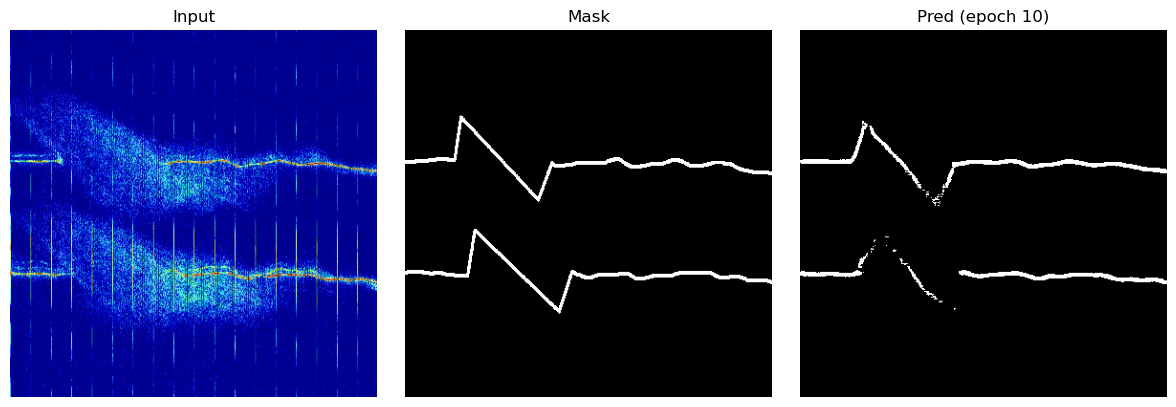

418/418 ━━━━━━━━━━━━━━━━━━━━ 1448s 3s/step - disc_loss: 0.7368 - gen_loss: 99.9670 - val_dice_score: 0.6352 - val_loss: 99.9004
Epoch 11/200
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - disc_loss: 0.6523 - gen_loss: 98.7964[Checkpoint saved] Epoch 11
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


In [ ]:
generator = build_generator()
discriminator = build_discriminator()
g_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
d_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
pix2pix_model = Pix2PixModel(generator, discriminator, g_opt, d_opt)

train_ds = tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final)).shuffle(512).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

ckpt_dir = "./ckpts_pix2pix_all_data"
os.makedirs(ckpt_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(generator=generator, discriminator=discriminator, g_opt=g_opt, d_opt=d_opt, epoch=tf.Variable(0,dtype=tf.int64))
manager = tf.train.CheckpointManager(ckpt, ckpt_dir, max_to_keep=EPOCHS)

if manager.latest_checkpoint:
    ckpt.restore(manager.latest_checkpoint).expect_partial()
    initial_epoch = int(ckpt.epoch.numpy())
    print(f"Načítaný checkpoint: {manager.latest_checkpoint}, pokračujem od epochy {initial_epoch+1}")
else:
    initial_epoch = 0
    print("Začínam tréning od začiatku")

show_cb = ShowPredictionCallback(generator, X_test[0], y_test[0])
save_best_cb = SaveBestFullGenerator(generator, "best_pix2pix_all_data.keras", monitor="val_dice_score", mode="max")
epoch_ckpt_cb = EpochCheckpoint(ckpt, manager)
early_cb = tf.keras.callbacks.EarlyStopping(monitor="val_dice_score", patience=10, mode="max", restore_best_weights=True)

pix2pix_model.compile()
pix2pix_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=initial_epoch,
    epochs=EPOCHS,
    callbacks=[save_best_cb, epoch_ckpt_cb, early_cb, show_cb],
    verbose=1,
)